# MrLavaLoba

A stochastic model for lava flows. There are just a small set of variables that must be set, and they will be described below.



In [1]:
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import cartopy.crs as ccrs
import sys
import glob
%matplotlib inline

In [2]:
sys.path.insert(0, "/home/jovyan/shared/Libraries/")
import victor

### MrLavaLoba currently does not have official documentation, so we provide a simple explanation to lead users through the process.


##### Use `run_name` to set the name of the run. (used to save the parameters and the output)

##### Use `source` to set the relative path/file name of the ASCII digital elevation model

##### Use `vent_flag` to select how multiple initial coordinates are treated:
1. `vent_flag = 0`: The initial lobes are on the vents coordinates and the flows start initially from the first vent, then fron the second, and so on.
2. `vent_flag = 1`: The initial lobes are chosen randomly from the vent coordinates and each vent has the same probability
3. `vent_flag = 2`: The initial lobes are on the polyline connecting the vents and all points on the polyline have the same probability
4. `vent_flag = 3`: The initial lobes are on the polyline connecting the vents and all segments on the polyline have the same probability

##### Use `x_vent` and `y_vent` lists to set the eastings and northings of the vent(s) of the volcano

##### If the `hazard_flag` flag is set to 1 then a raster map is saved where the values represent the probability of a cell to be covered. 

##### Use `masking_threshold` to set the fraction of the volume emplaced or the area invaded according to `flag_threshold` used to save the run_name_\*_masked.asc files. THis allows cutting the "tails" with a low thickness (\*_thickness_masked.asc) and a low probability (\*_hazard_masked.asc). The file is used also to check the convergence of the solutions increasing the number of flows The full outputs are saved in the files run_name_\*_full.asc The masked files are saved only when masking_thresold < 1.

In [3]:
run_name="hawaii"

source = "MaunaLoa.asc"

vent_flag = 0

x_vent = [ 234500 ]

y_vent = [ 2160119 ]

hazard_flag = 0

masking_threshold = 0.97

### Enter the bounds you would like to crop the flow

Only change these if you have a very large/small flow, or a very high resolution DEM.

In [4]:
east_to_vent = 15000.0

west_to_vent = 15000.0

south_to_vent = 15000.0

north_to_vent = 15000.0

##### Use `n_flows` to set the number of flows

##### Use `min_n_lobes` and `max_n_lobes` for picking a range of lobes randomly generated per flow. Setting then equal will make it constant.

##### If the `volume_flag = 1` then the total volume is read in input, and the thickness or the area of the lobes are evaluated according to the `fixed_dimension_flag` flag and the relationship $V = n*area*T$. Otherwise the thickness and the area are read in input and the total volume is evaluated $V = n*area*T$.

##### Set `total_volume`. (this value is used only when volume_flag = 1) set "1" to be confirmed (in $m^3).

In [5]:
n_flows = 300

min_n_lobes = 5000

max_n_lobes = 5000

volume_flag = 1

total_volume = 36000000

##### Set `fixed_dimension_flag` to select which dimension of the lobe is fixed when volume_flag=1:
1. `fixed_dimension_flag = 1`: the area of the lobes is assigned
2. `fixed_dimension_flag = 2`: the thickness of the lobes is assigend

##### Set `lobe_area` ( only effective when volume_flag = 0 or fixed_dimension_flag = 1 )

##### Set `avg_lobe_thickness` ( only effective when volume_flag = 0 or fixed_dimension_flag  2 )

##### Set `thickness_ratio` between the thickness of the first lobe of the flow and the thickness of the last lobe.
1. `thickness_ratio` < 1: the thickness increases with lobe "age"
2. `thickness_ratio` = 1: all the lobes have the same thickness
3. `thickness_ratio` > 1: the thickness decreases with lobe "age"

##### Set `topo_mod_flag` if the topography is modified by the lobes and if the emplacement of new flows is affected by the changed slope
1. `topo_mod_flag` = 0: the slope does not changes
2. `topo_mod_flag` = 1: the slope is re-evaluated every n_flows_counter flows
3. `topo_mod_flag` = 2: the slope is re-evaluated every n_lobes_counter flows and every n_flows_counter flows

##### `n_flows_counter` is only effective when `topo_mod_flag` = 1 and defines the number of flows for the re-evaluation of the slope modified by the flow

##### `n_lobes_counter` is only effective when `topo_mod_flag` = 2 and defines the number of lobes for the re-evaluation of the slope modified by the flow

In [6]:
fixed_dimension_flag = 1

lobe_area = 2000

avg_lobe_thickness = 0.02

thickness_ratio = 0.038

topo_mod_flag = 2

n_flows_counter = 1

n_lobes_counter = 1000

##### Setting `thickening_parameter` (between 0 and 1) allows for a thickening of the flowm controlling the modification of the slope due to the presence of the flow.
1. `thickening_parameter` = 0: minimum thickening (maximum spreading)
2. `thickening_parameter` = 1: maximum thickening produced in the output

##### `Lobe_exponent` is associated to the probability that a new lobe will be far or close to the vent when the flag `start_from_dist_flag`=1. The closer to 0 `lobe_exponent` is the larger is the probability that the new lobe will be generated from a younger/farther lobe.
1. `lobe_exponent` = 1: there is a uniform probability distribution assigned to all the existing lobes for the choice of the next lobe from which a new lobe will be generated. 
2. `lobe_exponent` = 0: the new lobe is generated from the last one.

##### `max_slope_prob` is related to the probability that the direction of the new lobe is close to the maximum slope direction:
1. `max_slope_prob` = 0: all the directions have the same probability;
2. `max_slope_prob` > 0: the maximum slope direction has a larger probability, and it increases with the value of the parameter
3. `max_slope_prob` = 1: the direction of the new lobe is the maximum slope direction.

##### Inertial exponent: 
1. `inertial_exponent` = 0: the max probability direction for the new lobe is the max slope direction.
2. `inertial_exponent` > 0: the max probability direction for the new lobe takes into account the direction of the parent lobe and the inertia exponentially increases

In [7]:
thickening_parameter = 0.2

lobe_exponent = 0.01

max_slope_prob = 0.5

inertial_exponent = 0.125

### As a sanity check, we display the provided DEM, along with the location of the source vents.

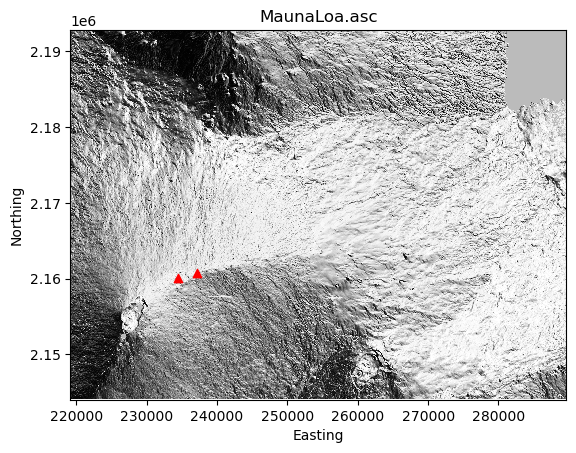

In [8]:
coords = np.array([x_vent,y_vent])
coords = np.transpose(coords)
victor.plot_dem(source, coords)

### Please run the next two cells to format the input and run the simulation.

In [9]:
inp = f"""run_name='{run_name}'
source = "{source}"
vent_flag = {vent_flag}
x_vent = {x_vent}
y_vent = {y_vent}
hazard_flag = {hazard_flag}
masking_threshold = {masking_threshold}
n_flows = {n_flows}
min_n_lobes = {min_n_lobes}
max_n_lobes = {max_n_lobes}
volume_flag = {volume_flag}
total_volume = {total_volume}
fixed_dimension_flag = {fixed_dimension_flag}
lobe_area = {lobe_area}
avg_lobe_thickness = {avg_lobe_thickness}
thickness_ratio = {thickness_ratio}
topo_mod_flag = {topo_mod_flag}
n_flows_counter = {n_flows_counter}
n_lobes_counter = {n_lobes_counter}
thickening_parameter = {thickening_parameter}
lobe_exponent = {lobe_exponent}
max_slope_prob = {max_slope_prob}
inertial_exponent = {inertial_exponent}
east_to_vent = {east_to_vent}
west_to_vent = {west_to_vent}
south_to_vent = {south_to_vent}
north_to_vent = {north_to_vent}"""
out = open("input_data.py",'w')
out.write(inp)
out.close()

In [10]:
subprocess.run("python mr_lava_loba.py",shell=True, stderr=subprocess.DEVNULL)


Mr Lava Loba by M.de' Michieli Vitturi and S.Tarquini

x_vent_end not used
y_vent_end not used
fissure_probabilities not used
Run name hawaii_004

Maximum number of lobes 5000
Average Lobe thickness = 0.012000 m

west_to_vent 5000.0
x_vent [234500, 237215]
Crop flag =  True
MaunaLoa.npy  exists
Cropping of original DEM
xW,xE,yS,yN 229500.0 242215.0 2155119.0 2165775.0
iW,iE,jS,jN 345 770 370 726

Time to read DEM 0.10606409299999986s
Channel parameters not defined:
- channel_file
- d1
- d2
- eps
- alfa_chaneel

Restart_files not used
max_semiaxis 39.89422804014327
max_cells 5
End pre-processing

[====================] 100% 0:00:01

Total number of lobes 1500000 Average number of lobes 5000

Time elapsed 21.901453426 sec. / 0 min.

Saving files

hawaii_004_thickness_full.asc saved
Union_diff_file not defined

Masking threshold 0.97
Total volume 173142.17516254235  m3 Masked volume 166183.93410244596  m3 Volume fraction 0.9598119807980686
Total area 8801100.0  m2 Masked area 4599000.0  

CompletedProcess(args='python mr_lava_loba.py', returncode=0)

### Model output

Depending on the parameters and DEM, the output will have a varying number of output files. 

Please reference the output folder and choose between the different numbered runs. For simplicity, you may enter "latest" to load the most recent output. Otherwise, all you must do is enter the number after the name of the run. E.g. "runname_003......" requires entering "3" in the next cell.

All subsequent cells can be run without further interaction.

In [14]:
run_num = "0"

In [18]:
if run_num=="latest":
    out = glob.glob(f'{run_name}*thickness_masked*.asc')
    filename = out[-1]
else:
    run_num = run_num.zfill(3)
    filename = run_name + "_" + run_num + "_" + "thickness_masked" + "_0_"+ str(int(masking_threshold*100))+".asc"
filename

'hawaii_004_thickness_masked_0_97.asc'

Text(0.5, 1.0, 'Lava Flow')

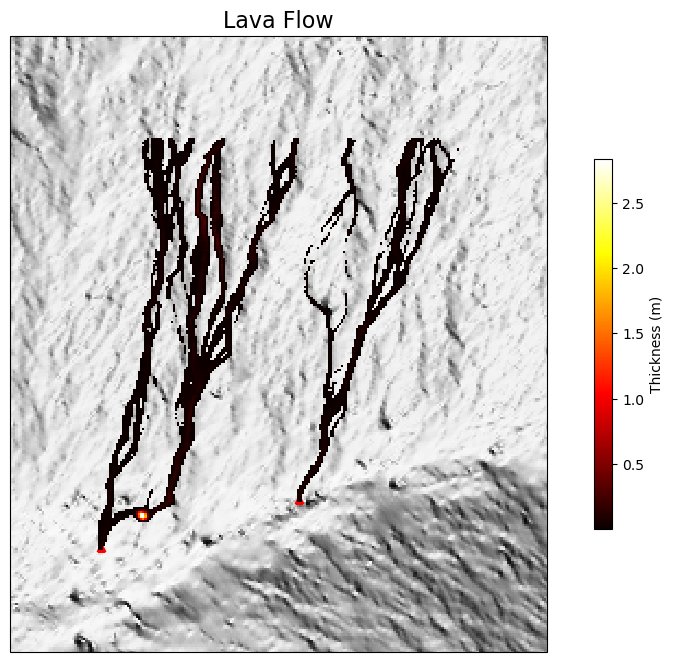

In [19]:
fig = plt.figure(figsize=(12, 8))
ax = plt.axes()

victor.plot_flow(source,filename, axes=ax,coords=coords, zoom=False)
    
ax.set_title('Lava Flow', fontsize=16)